In [21]:
#Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import joblib

#Load dataset
df = pd.read_csv(r"C:\Users\USER\PycharmProjects\component2_traffic\traffic_simulation\final_dataset_manual.csv")



In [22]:
#  Remove outliers from numeric columns
numeric_cols = ["duration", "waiting_time",  "route_length", "average_speed", "time_loss", "arrival_time"]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
         (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df = df[mask].reset_index(drop=True)

print("Rows after removing outliers:", df.shape[0])

#Feature selection
features = ["duration", "route_length", "average_speed", "time_loss"]
X = df[features]
y = df["waiting_time"]
#Handle Missing Values
X = X.fillna(X.median())

Rows after removing outliers: 1515


In [23]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
#Hyperparameter tuning
param_grid = {
    "n_estimators": [200, 300, 400],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.7, 0.8, 1.0]
}

gbr = GradientBoostingRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

#Best model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

#Predictions
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

#Clip negative predictions
y_train_pred = y_train_pred.clip(min=0)
y_test_pred = y_test_pred.clip(min=0)


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV Score: 0.9839512965747845


In [25]:
#Evaluate metrics
y_train_actual = y_train
y_test_actual = y_test

train_r2 = r2_score(y_train_actual, y_train_pred)
test_r2 = r2_score(y_test_actual, y_test_pred)
train_mae = mean_absolute_error(y_train_actual, y_train_pred)
test_mae = mean_absolute_error(y_test_actual, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))

print(f"Train R2: {train_r2:.5f}, Train MAE: {train_mae:.3f}, Train RMSE: {train_rmse:.3f}")
print(f"Test R2: {test_r2:.5f}, Test MAE: {test_mae:.3f}, Test RMSE: {test_rmse:.3f}")


Train R2: 0.99268, Train MAE: 7.405, Train RMSE: 10.407
Test R2: 0.98369, Test MAE: 10.423, Test RMSE: 16.175


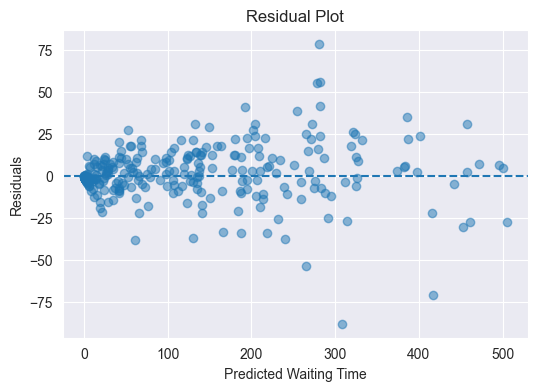

In [26]:
#Residual plot
residuals = y_test_actual - y_test_pred
plt.figure(figsize=(6,4))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted Waiting Time")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Feature Importance:
         Feature  Importance
3      time_loss    0.982017
2  average_speed    0.012837
1   route_length    0.002848
0       duration    0.002298


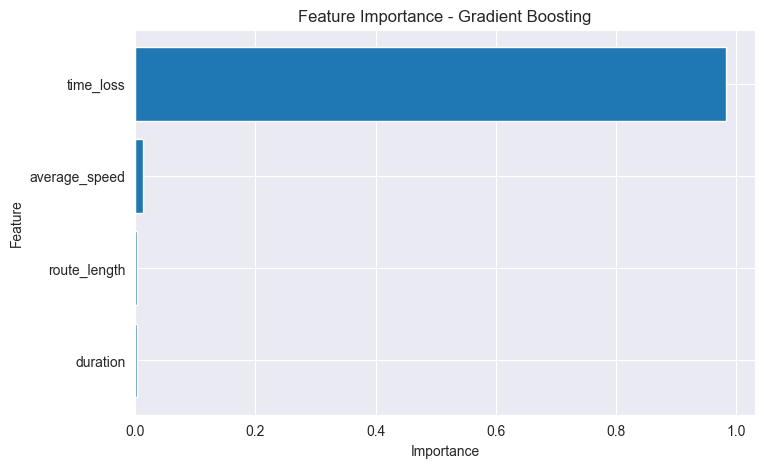

In [27]:
#Feature Importance
importances = best_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(8,5))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Gradient Boosting")
plt.gca().invert_yaxis()  # highest importance on top
plt.show()


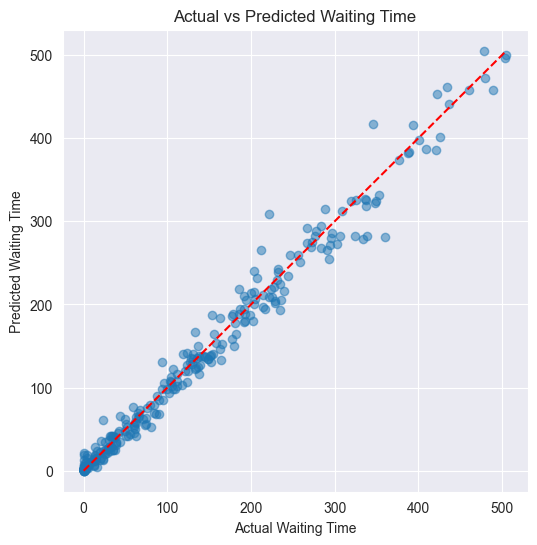

In [28]:
#Actual vs Predicted plot
plt.figure(figsize=(6,6))
plt.scatter(y_test_actual, y_test_pred, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()],
         [y_test_actual.min(), y_test_actual.max()],
         'r--')  # diagonal line for perfect prediction
plt.xlabel("Actual Waiting Time")
plt.ylabel("Predicted Waiting Time")
plt.title("Actual vs Predicted Waiting Time")
plt.show()

In [29]:
#Comparison table with vehicle ID
comparison = pd.DataFrame({
    "Vehicle ID": df.iloc[y_test.index]["vehicle_id"],
    "Actual Waiting Time": y_test_actual,
    "Predicted Waiting Time": y_test_pred,
    "Error": abs(y_test_actual - y_test_pred)
})

print(comparison.sort_values("Error", ascending=False).head(20))

      Vehicle ID  Actual Waiting Time  Predicted Waiting Time      Error
1198        1297                221.0              308.761646  87.761646
1311        1512                360.0              281.073558  78.926442
924          779                346.0              416.958211  70.958211
240           63                338.0              281.648765  56.351235
1463        1854                334.0              278.501544  55.498456
938          863                212.0              265.375363  53.375363
478          324                324.0              281.908960  42.091040
128           86                234.0              192.730000  41.270000
1288        1484                293.0              253.982190  39.017810
353          383                 23.0               60.980764  37.980764
852          930                203.0              240.417192  37.417192
1170        1453                 94.0              130.842765  36.842765
1185        1176                421.0              

In [30]:
#Save model
joblib.dump(best_model, "manual_waiting_time_model.pkl")
print("Model saved as manual_waiting_time_model_log.pkl")

Model saved as manual_waiting_time_model_log.pkl
